# Superstore Sales Workflow Tutorial

This notebook walks through cleaning the Superstore dataset, designing a relational structure, creating an SQLite database, and running example SQL queries and visualizations.

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

In [1]:
print('test')

test


## 1️) Load and Inspect the Dataset

In [3]:
# reading error codes + research is how you can learn if there is different encoding, as seen below
df = pd.read_csv('../data/Superstore.csv', encoding='ISO-8859-1')
df.head()
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

### Double check some datatypes, and for nulls and duplicates:

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

This data is incredibly clean - we can see there are no null values and no duplicates. However, there are some dates that could be saved in a better format.

## 2) Data Cleaning

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [7]:
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [8]:
df.Segment.unique()

<StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str

In [9]:
df.rename(columns={"Segment":"customer_category"}, inplace=True)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,customer_category,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


With real data, it is very likely more cleaning and wrangling would be required. 

## 3) Build Relational Tables

In [10]:
conn = sqlite3.connect('../data/superstore.db')

customers_df = df[['Customer ID','Customer Name','customer_category','City','State','Region', 'Postal Code']].drop_duplicates().rename(columns={
    'Customer ID':'customer_id',
    'Customer Name':'customer_name',
    'City':'city',
    'State':'state',
    'Region':'region',
    'Postal Code': 'zipcode'
})

products_df = df[['Product ID','Category','Sub-Category','Product Name']].drop_duplicates().rename(columns={
    'Product ID':'product_id',
    'Category':'category',
    'Sub-Category':'subcategory',
    'Product Name':'product_name'
})

orders_df = df[['Order ID','Order Date','Ship Date','Ship Mode','Customer ID']].drop_duplicates().rename(columns={
    'Order ID':'order_id',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Ship Mode':'ship_mode',
    'Customer ID':'customer_id'
})

order_details_df = df[['Order ID','Product ID','Sales','Quantity','Discount','Profit']].rename(columns={
    'Order ID':'order_id',
    'Product ID':'product_id'
})


customers_df.to_sql('customers', conn, index=False, if_exists='replace')
products_df.to_sql('products', conn, index=False, if_exists='replace')
orders_df.to_sql('orders', conn, index=False, if_exists='replace')
order_details_df.to_sql('order_details', conn, index=False, if_exists='replace')
conn.commit()

In [11]:
for name, df in [
    ('customers', customers_df),
    ("products", products_df),
    ("orders", orders_df),
    ("order_details", order_details_df)
]:
    df.to_csv(f'../data/{name}.csv')

## 4) Make Some Queries!

### Which customer segments bring in the most revenue and profit?

In [12]:
query1 = """ SELECT 
    c.customer_category,
    ROUND(SUM(od.sales), 2) AS total_sales,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY total_sales DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,customer_category,total_sales,total_profit
0,Consumer,8380282.43,973085.86
1,Corporate,5044899.83,660287.69
2,Home Office,2964459.36,434344.01


### What are the top 10 customers by total sales?

In [14]:
query2 = """ Your code here! """
query2 = """ SELECT 
    c.customer_name,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.customer_name
ORDER BY total_sales DESC
LIMIT 10;
"""
result2 = pd.read_sql(query2, conn)
result2

,customer_name,total_sales
0,Ken Lonsdale,155927.52
1,Sanjit Engle,134303.82
2,Clay Ludtke,130566.55
3,Adrian Barton,130262.14
4,Sanjit Chand,127281.01
5,Sean Miller,125215.25
6,Edward Hooks,123730.56
7,Greg Tran,118201.20
8,Seth Vernon,114709.50
9,John Lee,107799.15


### Which product categories and subcategories are the most profitable overall?

In [16]:
query3 = """ Your code here! """
query3 = """
SELECT
    p.category,
    p.subcategory,
    ROUND(SUM(od.profit), 2) AS total_profit
FROM order_details od
JOIN products p ON od.product_id = p.product_id
GROUP BY p.category, p.subcategory
ORDER BY total_profit DESC;
"""
result3 = pd.read_sql(query3, conn)
result3
result3

,category,subcategory,total_profit
0,Technology,Copiers,55617.82
1,Technology,Accessories,48359.05
2,Technology,Phones,46936.19
3,Office Supplies,Paper,36994.53
4,Office Supplies,Binders,30373.20
5,Furniture,Chairs,26707.65
6,Office Supplies,Storage,21408.70
7,Office Supplies,Appliances,18514.49
8,Furniture,Furnishings,14569.59
9,Office Supplies,Envelopes,6964.18


### What is the average discount given per category?

In [18]:
query4 = """ Your code here! """
query4 = """
SELECT
    p.category,
    ROUND(AVG(od.discount), 2) AS avg_discount
FROM order_details od
JOIN products p ON od.product_id = p.product_id
GROUP BY p.category
ORDER BY avg_discount DESC;
"""
result4 = pd.read_sql(query4, conn)
result4
result4

,category,avg_discount
0,Furniture,0.17
1,Office Supplies,0.16
2,Technology,0.13


### Which states or regions contribute the most to total sales?

In [20]:
query5 = """ Your code here! """
query5 = """
SELECT
    c.state,
    c.region,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.state, c.region
ORDER BY total_sales DESC
LIMIT 20;
"""
result5 = pd.read_sql(query5, conn)
result5
result5

,state,region,total_sales
0,California,West,3314837.69
1,New York,East,1859365.37
2,Texas,Central,1547925.76
3,Pennsylvania,East,886105.68
4,Washington,West,862298.69
5,Illinois,Central,843352.76
6,Ohio,East,707747.69
7,Florida,South,635637.78
8,North Carolina,South,437938.43
9,Michigan,Central,432428.02


### How many orders were shipped late (where Ship Date > Order Date + 3 days)?

In [22]:
query6 = """ Your code here! """
query6 = """
SELECT
    COUNT(*) AS late_orders
FROM orders
WHERE DATE(ship_date) > DATE(order_date, '+3 day');
"""
result6 = pd.read_sql(query6, conn)
result6
result6

,late_orders
0,3391


### Which month or year had the highest total sales?

In [24]:
query7 = """ Your code here! """
query7 = """
SELECT
    strftime('%Y', o.order_date) AS sales_year,
    strftime('%m', o.order_date) AS sales_month,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
GROUP BY sales_year, sales_month
ORDER BY total_sales DESC
LIMIT 10;
"""
result7 = pd.read_sql(query7, conn)
result7
result7

,sales_year,sales_month,total_sales
0,2014,11,112326.47
1,2013,12,97237.42
2,2014,09,90488.72
3,2014,12,90474.60
4,2013,11,82192.32
5,2011,09,81777.35
6,2011,11,78628.72
7,2014,10,77793.76
8,2012,11,75972.56
9,2012,12,74919.52


### What are the most frequently ordered products?

In [26]:
query8 = """ Your code here! """
query8 = """
SELECT
    p.product_name,
    ROUND(SUM(od.quantity), 0) AS total_quantity
FROM order_details od
JOIN products p ON od.product_id = p.product_id
GROUP BY p.product_id, p.product_name
ORDER BY total_quantity DESC
LIMIT 10;
"""
result8 = pd.read_sql(query8, conn)
result8
result8

,product_name,total_quantity
0,Imation 16GB Mini TravelDrive USB 2.0 Flash Drive,75.0
1,Logitech P710e Mobile Speakerphone,75.0
2,Xerox 1881,70.0
3,Xerox 1908,70.0
4,GBC Premium Transparent Covers with Diagonal L...,67.0
5,"Situations Contoured Folding Chairs, 4/Set",64.0
6,Avery Arch Ring Binders,64.0
7,Ibico Recycled Linen-Style Covers,64.0
8,Chromcraft Round Conference Tables,61.0
9,Logitech G19 Programmable Gaming Keyboard,60.0


### Which customers placed more than 5 orders total?

In [28]:
query9 = """
SELECT column1, column2
FROM table_name
WHERE some_condition
"""
query9 = """
SELECT
    c.customer_name,
    COUNT(DISTINCT o.order_id) AS order_count,
    ROUND(SUM(od.sales), 2) AS total_sales
FROM orders o
JOIN order_details od ON o.order_id = od.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_id, c.customer_name
HAVING order_count > 5
ORDER BY order_count DESC, total_sales DESC;
"""
result9 = pd.read_sql(query9, conn)
result9
result9

,customer_name,order_count,total_sales
0,Emily Phan,17,93127.03
1,Zuschuss Carroll,13,104334.19
2,Joel Eaton,13,87890.60
3,Sally Hughsby,13,44288.91
4,Patrick Gardner,13,37042.88
...,...,...,...
459,Cari Schnelling,6,3225.79
460,John Huston,6,3173.46
461,Sonia Sunley,6,2510.94
462,Joy Daniels,6,2312.58


### What’s the profit margin (profit ÷ sales) by category or segment?

In [30]:
query10 = """ Your code here! """
query10 = """
SELECT
    c.customer_category,
    ROUND(
        CASE WHEN SUM(od.sales) = 0 THEN 0
             ELSE SUM(od.profit) / SUM(od.sales) * 100
        END
    , 2) AS profit_margin_pct
FROM order_details od
JOIN orders o ON od.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_category
ORDER BY profit_margin_pct DESC;
"""
result10 = pd.read_sql(query10, conn)
result10
result10

,customer_category,profit_margin_pct
0,Home Office,14.65
1,Corporate,13.09
2,Consumer,11.61


### 5) Visualize it!

From your ten results, select at least 4 to utilize in a meaningful visualization. 

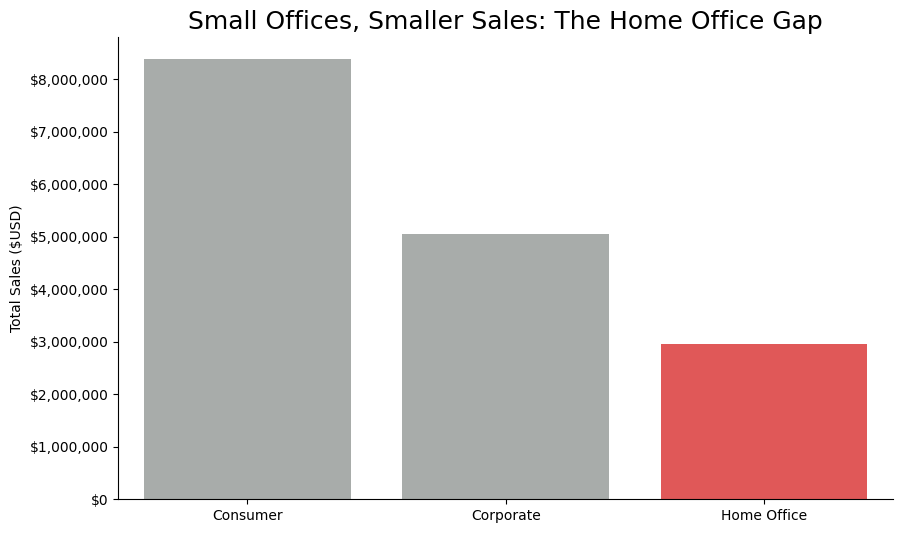

In [31]:
# example using result1
plt.figure(figsize=(10,6))
colors = ["#a7adaa", "#a7adaa", "#f74141" ]
sns.barplot(result1, x='customer_category', y='total_sales', palette=colors, hue='customer_category', legend=False)
plt.title('Small Offices, Smaller Sales: The Home Office Gap',fontsize=18)
plt.xlabel(None)
plt.ylabel('Total Sales ($USD)')

#for those wondering how to get rid of scientific notation! Set style to plain:
plt.ticklabel_format(style='plain', axis='y')

#mticker is a great library for helping tick mark formatting, such as adding commas and dollar signs in this case
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

#using the seaborn library, despining is way easier!
sns.despine()
plt.show()


In [ ]:
# visualization one code here

In [ ]:
# visualization two code here

In [ ]:
# visualization three code here

In [ ]:
# visualization four code here